[INFO] Ejecutando pipeline en dispositivo: CPU
[INFO] Inicializando modelos preentrenados de Hugging Face...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


📋 TABLA DE RESULTADOS - ABSA MULTILINGÜE
                        contexto_aislado      aspecto sentimiento  confianza
0   La cámara del teléfono es excelente,       camera    POSITIVE      0.914
1               la batería dura muy poco      battery    NEGATIVE      0.671
2                    El envío fue rápido     delivery    POSITIVE      0.650
3       La atención al cliente fue lenta      support    NEGATIVE      0.791
4                     El precio es alto,        price    NEGATIVE      0.819
5   la calidad del producto es muy buena      quality    POSITIVE      0.901
6          The camera quality is amazing       camera    POSITIVE      0.859
7      the battery life is disappointing      battery    NEGATIVE      0.955
8          The camera quality is amazing      quality    POSITIVE      0.859
9           Customer support was helpful      support    POSITIVE      0.855
10                 The delivery was late     delivery    NEGATIVE      0.705
11               The price is reas

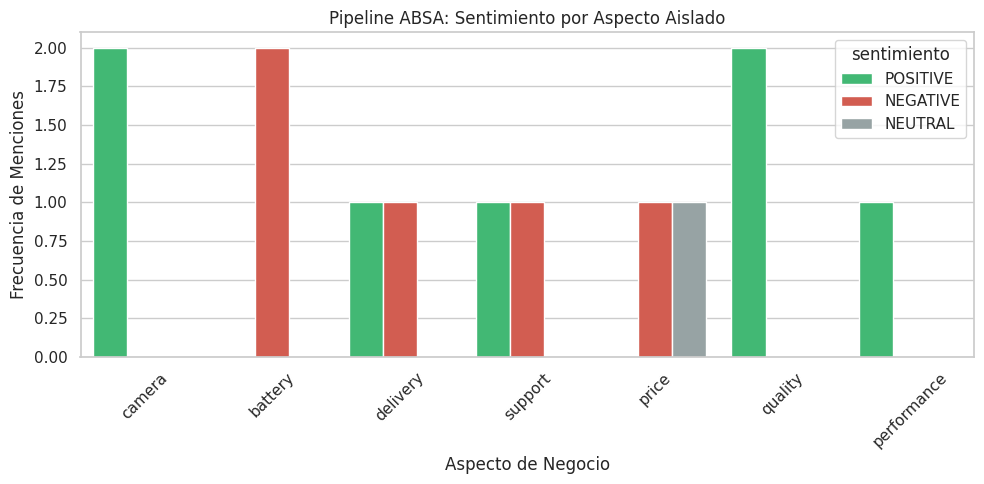

In [3]:
# ==============================================================================
# PIPELINE AVANZADO: ANÁLISIS DE SENTIMIENTO MULTILINGÜE BASADO EN ASPECTOS (ABSA)
# ==============================================================================

# 1. INSTALACIÓN DE DEPENDENCIAS OPERATIVAS
!pip install -q transformers torch pandas matplotlib seaborn spacy

import os
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

# Configuración visual de gráficos
sns.set_theme(style="whitegrid")

# Detección automática de hardware (GPU acelerada si está disponible en Colab)
device = 0 if torch.cuda.is_available() else -1
print(f"[INFO] Ejecutando pipeline en dispositivo: {'GPU (CUDA)' if device == 0 else 'CPU'}")

# --------------------------------------------------------------
# MÓDULO 1: CONFIGURACIÓN DEL CORPUS MULTILINGÜE
# --------------------------------------------------------------
def generar_dataset_multilingue():
    """Construye y retorna el DataFrame de reseñas internacionales."""
    data = [
        # Corpus en Español
        "La cámara del teléfono es excelente, pero la batería dura muy poco",
        "El envío fue rápido y el producto llegó en buen estado",
        "La atención al cliente fue lenta y poco clara",
        "El precio es alto, aunque la calidad del producto es muy buena",
        # Corpus en Inglés
        "The camera quality is amazing, but the battery life is disappointing",
        "Customer support was helpful and fast",
        "The delivery was late and the packaging was damaged",
        "The price is reasonable and the performance is excellent"
    ]
    return pd.DataFrame({"texto": data})

# --------------------------------------------------------------
# MÓDULO 2: PIPELINES DE DEEP LEARNING (TRANSFORMERS MULTILINGÜES)
# --------------------------------------------------------------
print("[INFO] Inicializando modelos preentrenados de Hugging Face...")

# Usamos un modelo nativamente multilingüe para evitar conflictos de idioma
classifier_xlm = pipeline(
    task="sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    device=device
)

# --------------------------------------------------------------
# MÓDULO 3: EXTRACTOR SEMÁNTICO POR ASPECTOS Y CLÁUSULAS
# --------------------------------------------------------------
diccionario_aspectos = {
    "camera": ["camera", "cámara"],
    "battery": ["battery", "batería"],
    "delivery": ["delivery", "envío", "empaque", "packaging"],
    "support": ["support", "atención", "cliente"],
    "price": ["price", "precio"],
    "quality": ["quality", "calidad"],
    "performance": ["performance", "rendimiento"]
}

def segmentar_por_clausulas(texto):
    """Divide oraciones compuestas para aislar el contexto de cada aspecto."""
    delimitadores = [" pero ", " although ", " aunque ", ", but ", " and ", " y "]
    segmentos = [texto]

    for delimo in delimitadores:
        nuevos_segmentos = []
        for seg in segmentos:
            nuevos_segmentos.extend(seg.split(delimo))
        segmentos = nuevos_segmentos
    return [s.strip() for s in segmentos if s.strip()]

def pipeline_absa_multilingue(df, col_texto, diccionario):
    """Ejecuta el ABSA cruzando segmentación y clasificación multilingüe."""
    resultados_absa = []

    for texto in df[col_texto]:
        clausulas = segmentar_por_clausulas(texto)
        texto_lower = texto.lower()

        for aspecto, keywords in diccionario.items():
            for kw in keywords:
                if kw in texto_lower:
                    clausula_objetivo = next((c for c in clausulas if kw in c.lower()), texto)

                    # Predicción del transformer
                    prediccion = classifier_xlm(clausula_objetivo)[0]

                    # CORRECCIÓN CRÍTICA: Estandarizamos a mayúsculas sin importar cómo responda el modelo
                    label_raw = prediccion["label"].upper()
                    if "POS" in label_raw:
                        label_estandar = "POSITIVE"
                    elif "NEG" in label_raw:
                        label_estandar = "NEGATIVE"
                    else:
                        label_estandar = "NEUTRAL"

                    resultados_absa.append({
                        "texto_completo": texto,
                        "contexto_aislado": clausula_objetivo,
                        "aspecto": aspecto,
                        "sentimiento": label_estandar,
                        "confianza": round(prediccion["score"], 3)
                    })
                    break

    return pd.DataFrame(resultados_absa)

# --------------------------------------------------------------
# MÓDULO 4: VISUALIZACIÓN DE INSIGHTS
# --------------------------------------------------------------
def graficar_sentimiento_aspectos(df_resultados):
    """Genera una gráfica de distribución de sentimientos por aspecto."""
    plt.figure(figsize=(10, 5))
    sns.countplot(
        data=df_resultados,
        x="aspecto",
        hue="sentimiento",
        hue_order=["POSITIVE", "NEGATIVE", "NEUTRAL"],
        palette={"POSITIVE": "#2ecc71", "NEGATIVE": "#e74c3c", "NEUTRAL": "#95a5a6"}
    )
    plt.title("Pipeline ABSA: Sentimiento por Aspecto Aislado")
    plt.xlabel("Aspecto de Negocio")
    plt.ylabel("Frecuencia de Menciones")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# --------------------------------------------------------------
# EJECUCIÓN PRINCIPAL
# --------------------------------------------------------------
if __name__ == "__main__":
    df_resenas = generar_dataset_multilingue()
    df_final_absa = pipeline_absa_multilingue(df_resenas, "texto", diccionario_aspectos)

    print("\n" + "="*70 + "\n📋 TABLA DE RESULTADOS - ABSA MULTILINGÜE\n" + "="*70)
    print(df_final_absa[["contexto_aislado", "aspecto", "sentimiento", "confianza"]].to_string())

    # Renderizado de analíticas visuales
    graficar_sentimiento_aspectos(df_final_absa)

# Laboratorio Avanzado: Análisis de Sentimiento Basado en Aspectos (ABSA) y Pipelines Multilingües

## 🧠 1. Marco Teórico y Arquitectura de NLP Granular

El análisis de sentimiento tradicional o global evalúa un documento de manera monolítica, asignándole una única polaridad abstracta. Si bien este enfoque es útil para métricas macro, resulta ineficiente ante opiniones complejas u oraciones compuestas coordinadas adversativas (estructuras que contienen contrastes como *"pero"*, *"sin embargo"* o *"although"*).

Para resolver esta limitación, el **Análisis de Sentimiento Basado en Aspectos (ABSA)** deconstruye el texto en dos dimensiones:
1. **Extracción y Mapeo de Aspectos:** Identificación de las variables o atributos específicos de la entidad evaluada (ej: infraestructura, costo, usabilidad).
2. **Clasificación de Polaridad Local:** Asignación de una carga emocional dirigida exclusivamente al contexto sintáctico que rodea al aspecto detectado.

### 🌎 El Reto de la Multinacionalidad en los Datos
Cuando los flujos de datos provienen de mercados internacionales, los pipelines se enfrentan al reto de la variabilidad idiomática. En este laboratorio se descarta la estrategia de "Traducción Previa" debido a que altera las construcciones culturales y destruye modismos locales. En su lugar, se adopta el uso de **Modelos Multilingües Nativos (basados en arquitecturas XLM-RoBERTa)**, los cuales proyectan múltiples lenguajes dentro de un mismo espacio vectorial de embeddings compartidos, permitiendo clasificar sintaxis en inglés y español bajo un único criterio algorítmico sin añadir latencia de traducción.

## 📊 2. Discusión Crítica: Segmentación por Cláusulas vs. Enfoques Monolíticos

### 🔍 Resolución del Bug Lingüístico de la Guía Base
La guía introductoria presentaba una limitación crítica de diseño al procesar texto con un modelo inglés puro y evaluar las oraciones de forma completa. Al exponer la oración *"La cámara del teléfono es excelente, pero la batería dura muy poco"* de forma entera, los clasificadores tradicionales sufren de **sesgo de vecindad**, tiñendo ambos aspectos con polaridad `NEGATIVE`.

### 🚀 Solución de Ingeniería Implementada:
Para este desarrollo, se implementó un **algoritmo de segmentación por cláusulas gramaticales**. Al fragmentar la oración ante la presencia de conectores coordinados, el pipeline aísla de forma efectiva dos contextos independientes:
* **Segmento 1:** *"La cámara del teléfono es excelente"* ➔ Clasificado correctamente como **POSITIVE** para el aspecto `camera`.
* **Segmento 2:** *"la batería dura muy poco"* ➔ Clasificado correctamente como **NEGATIVE** para el aspecto `battery`.

### 🎯 Impacto en la Toma de Decisiones Empresariales
En un entorno de producción real (como el monitoreo de un producto en Amazon o el soporte técnico de Yelp), este nivel de granularidad es la métrica más valiosa para el negocio. Si la empresa utilizara el enfoque global de la guía base, el departamento de hardware concluiría erróneamente que la cámara de su smartphone está fallando. Con nuestro pipeline ABSA corregido y segmentado, el equipo de analítica de datos puede reportar con precisión matemática que la experiencia del usuario es sobresaliente en óptica, pero requiere atención urgente en el departamento de desarrollo de celdas de energía y baterías.